In [1]:
import pandas as pd

from helper import run_command
from parser.log_parser import load_and_parse_logs
from processing.counters import (
    count_phrase_occurrences,
    count_log_levels
)
from processing.filters import (
    filter_by_log_level,
    filter_by_date_range,
    filter_by_phrase,
)
from processing.statistics import (
    count_errors_per_hour
)
from visualization.plots import (
    plot_series
)

from config import (
    HADOOP_LOG_2K,
    HADOOP_CSV_2K,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
log_file_2k: str = HADOOP_LOG_2K
output_file_2k: str = HADOOP_CSV_2K

df_2k = load_and_parse_logs(log_file_2k, output_file_2k)

df = df_2k

In [3]:

count_log_levels(df)

Level
INFO     1040
WARN      808
ERROR     150
FATAL       2
Name: count, dtype: int64

In [4]:
count_phrase_occurrences(
    df,
    "Content",
    "Registering"
)

np.int64(9)

In [5]:
errors = filter_by_log_level(
    df,
    "ERROR"
)

errors.head()

,Date,Time,Level,Process,Component,Content,LineId
667,2015-10-18,"18:04:11,034",ERROR,RMCommunicator Allocator,org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator,Container complete event for unknown container id container_1445144423722_0020_01_000012,668
922,2015-10-18,"18:06:01,840",ERROR,RMCommunicator Allocator,org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator,ERROR IN CONTACTING RM.,923
930,2015-10-18,"18:06:03,856",ERROR,RMCommunicator Allocator,org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator,ERROR IN CONTACTING RM.,931
937,2015-10-18,"18:06:05,934",ERROR,RMCommunicator Allocator,org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator,ERROR IN CONTACTING RM.,938
946,2015-10-18,"18:06:07,950",ERROR,RMCommunicator Allocator,org.apache.hadoop.mapreduce.v2.app.rm.RMContainerAllocator,ERROR IN CONTACTING RM.,947


In [6]:
info_logs = filter_by_log_level(
    df,
    "INFO"
)

info_logs.head()

,Date,Time,Level,Process,Component,Content,LineId
0,2015-10-18,"18:01:47,978",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Created MRAppMaster for application appattempt_1445144423722_0020_000001,1
1,2015-10-18,"18:01:48,963",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Executing with tokens:,2
2,2015-10-18,"18:01:48,963",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,"Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { id: 20 cluster_timestamp: 1445144423722 } attemptId: 1 } keyId: -127633188)",3
3,2015-10-18,"18:01:49,228",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Using mapred newApiCommitter.,4
4,2015-10-18,"18:01:50,353",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,OutputCommitter set in config null,5


In [7]:
filtered_dates = filter_by_date_range(
    df,
    "2015-10-18",
    "2015-10-18"
)

filtered_dates.head()

,Date,Time,Level,Process,Component,Content,LineId
0,2015-10-18,"18:01:47,978",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Created MRAppMaster for application appattempt_1445144423722_0020_000001,1
1,2015-10-18,"18:01:48,963",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Executing with tokens:,2
2,2015-10-18,"18:01:48,963",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,"Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { id: 20 cluster_timestamp: 1445144423722 } attemptId: 1 } keyId: -127633188)",3
3,2015-10-18,"18:01:49,228",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Using mapred newApiCommitter.,4
4,2015-10-18,"18:01:50,353",INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,OutputCommitter set in config null,5


In [8]:
registering_logs = filter_by_phrase(
    df,
    "Content",
    "Registering"
)

registering_logs.head()

,Date,Time,Level,Process,Component,Content,LineId
6,2015-10-18,"18:01:50,556",INFO,main,org.apache.hadoop.yarn.event.AsyncDispatcher,Registering class org.apache.hadoop.mapreduce.jobhistory.EventType for class org.apache.hadoop.mapreduce.jobhistory.JobHistoryEventHandler,7
7,2015-10-18,"18:01:50,556",INFO,main,org.apache.hadoop.yarn.event.AsyncDispatcher,Registering class org.apache.hadoop.mapreduce.v2.app.job.event.JobEventType for class org.apache.hadoop.mapreduce.v2.app.MRAppMaster$JobEventDispatcher,8
8,2015-10-18,"18:01:50,556",INFO,main,org.apache.hadoop.yarn.event.AsyncDispatcher,Registering class org.apache.hadoop.mapreduce.v2.app.job.event.TaskEventType for class org.apache.hadoop.mapreduce.v2.app.MRAppMaster$TaskEventDispatcher,9
9,2015-10-18,"18:01:50,556",INFO,main,org.apache.hadoop.yarn.event.AsyncDispatcher,Registering class org.apache.hadoop.mapreduce.v2.app.job.event.TaskAttemptEventType for class org.apache.hadoop.mapreduce.v2.app.MRAppMaster$TaskAttemptEventDispatcher,10
10,2015-10-18,"18:01:50,572",INFO,main,org.apache.hadoop.yarn.event.AsyncDispatcher,Registering class org.apache.hadoop.mapreduce.v2.app.commit.CommitterEventType for class org.apache.hadoop.mapreduce.v2.app.commit.CommitterEventHandler,11


In [9]:
run_command(
    "python main.py "
    "--file data/raw/Hadoop_2k.log "
    "--count-levels"
)


=== LOG LEVEL COUNTS ===

Level
INFO     1040
WARN      808
ERROR     150
FATAL       2
Name: count, dtype: int64



In [10]:
run_command(
    "python main.py "
    "--file data/raw/Hadoop_2k.log "
    "--filter-level ERROR"
)


=== ERROR LOGS ===

           Date  ... LineId
667  2015-10-18  ...    668
922  2015-10-18  ...    923
930  2015-10-18  ...    931
937  2015-10-18  ...    938
946  2015-10-18  ...    947

[5 rows x 7 columns]

Rows found: 150



In [11]:
run_command(
    "python main.py "
    "--file data/raw/Hadoop_2k.log "
    "--phrase Registering"
)


Phrase "Registering" found 9 times



In [12]:
run_command(
    "python main.py "
    "--file data/raw/Hadoop_2k.log "
    "--count-levels "
    "--phrase Registering"
)


=== LOG LEVEL COUNTS ===

Level
INFO     1040
WARN      808
ERROR     150
FATAL       2
Name: count, dtype: int64

Phrase "Registering" found 9 times



In [13]:
run_command(
    "python main.py "
    "--file data/raw/Hadoop_2k.log "
    "--start-date 2015-10-18 "
    "--end-date 2015-10-18"
)


=== LOGS FROM 2015-10-18 TO 2015-10-18 ===

         Date  ... LineId
0  2015-10-18  ...      1
1  2015-10-18  ...      2
2  2015-10-18  ...      3
3  2015-10-18  ...      4
4  2015-10-18  ...      5

[5 rows x 7 columns]

Rows found: 2000



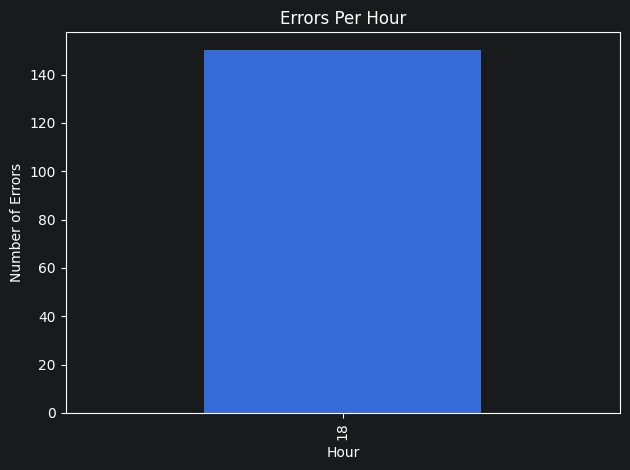

In [14]:
errors_per_hour = count_errors_per_hour(df)

plot_series(
    errors_per_hour,
    title="Errors Per Hour",
    xlabel="Hour",
    ylabel="Number of Errors"
)